## <mark>**WITH 126 IMAGES, IMPROVEMENTS MADE TO TEXTURE.PY**</mark>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore", message=".*encountered in matmul.*", category=RuntimeWarning)

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline



## correlation analysis (heatmap)

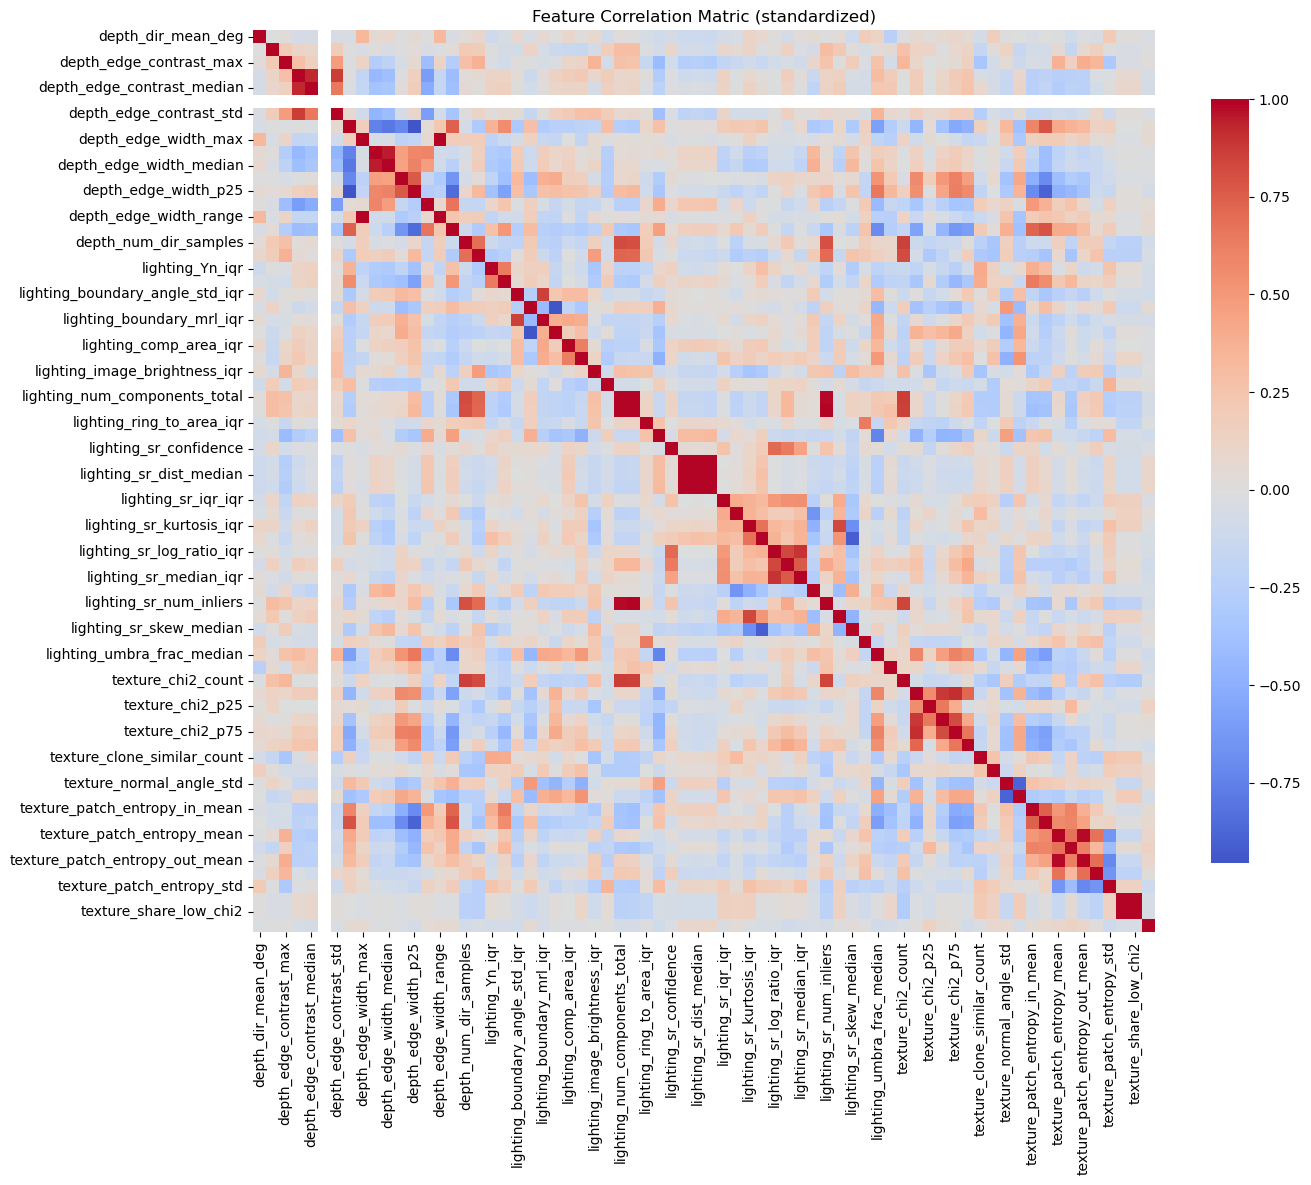


Top correlations with LABEL:

texture_patch_entropy_min          0.135752
texture_chi2_p25                   0.129816
texture_patch_entropy_std         -0.110814
lighting_sr_dist_p75               0.101388
lighting_ring_to_area_median      -0.097570
texture_patch_entropy_out_mean     0.096173
lighting_sr_dist_mean              0.093934
lighting_sr_log_ratio_spread      -0.092387
texture_patch_entropy_mean         0.092119
lighting_sr_dist_median            0.090697
lighting_umbra_frac_median        -0.086929
depth_num_dir_samples             -0.081235
lighting_boundary_angle_std_iqr   -0.081184
texture_chi2_std                  -0.078631
texture_clone_similar_max          0.076845
lighting_Yn_iqr                   -0.074306
lighting_sr_median_iqr            -0.072442
texture_normal_angle_std           0.072142
texture_normal_mrl                -0.071591
texture_patch_entropy_max          0.070987
Name: label, dtype: float64


In [3]:
# load data
path = "features_3.csv"

df = pd.read_csv(path)

# keep numeric columns
df_num = df.select_dtypes(include=[np.number])

assert "label" in df_num.columns, "Label column not found"

# standardize features
X = df_num.drop(columns=["label"])
y = df_num["label"]

X_std = (X - X.mean()) / (X.std() + 1e-8)

df_std = X_std.copy()
df_std["label"] = y.values

# correlation matrix
corr = df_std.corr(method="pearson")

# heatmap
plt.figure(figsize=(14,12))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=True,
    cbar_kws={"shrink": 0.8}
)
plt.title("Feature Correlation Matric (standardized)")
plt.tight_layout()
plt.show()

# sorted feature-label correlation
label_corr = corr["label"].drop("label").sort_values(key=np.abs, ascending=False)

print("\nTop correlations with LABEL:\n")
print(label_corr.head(20))

If two features are highly correlated:
- RF will split importance between them
- Neither will look dominant, but removing both can hurt performance.

So if you pick just the top 5 importances, may accidentally:
- Remove complementary correlated features
- Lose distributed signal

## logistic weights

In [4]:
# load data
CSV_PATH = "features_3.csv"

df = pd.read_csv(CSV_PATH)
df = df.select_dtypes(include=[np.number])

assert "label" in df.columns, "Label column not found"

X = df.drop(columns=["label"])
y = df["label"].values

feature_names = X.columns.tolist()

# -----------------------------
# standardize features
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Max abs value in X_scaled:", np.max(np.abs(X_scaled)))
print("All finite in X_scaled:", np.isfinite(X_scaled).all())

# -----------------------------
# train logistic regression
# -----------------------------
model = LogisticRegression(
    l1_ratio=1, # this means the penalty used is l1
    solver="liblinear",
    C=0.1,
    max_iter=2000
)

model.fit(X_scaled, y)

# -----------------------------
# extract weights and bias
# -----------------------------
weights = model.coef_[0]
bias = model.intercept_[0]

# combine into table
coef_df = pd.DataFrame({
    "feature": feature_names,
    "weight": weights,
    "abs_weight": np.abs(weights)
}).sort_values("abs_weight", ascending=False)

print("\n==============================")
print("LOGISTIC REGRESSION RESULTS")
print("==============================")
print(f"\nBias (intercept): {bias:.4f}")
print("\nTop 25 Features by |Weight|:\n")
print(coef_df.head(25))

# save full table
coef_df.to_csv("logistic_weights.csv", index=False)

# -----------------------------
# cross-validation accuracy
# -----------------------------
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
accs = []
fold_num = 1

for train_idx, test_idx in kf.split(X_scaled, y):
    X_tr, X_te = X_scaled[train_idx], X_scaled[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    model_cv = LogisticRegression(
        l1_ratio=1,
        solver="liblinear",
        max_iter=1000
    )
    model_cv.fit(X_tr, y_tr)

    w = model_cv.coef_[0]
    b = model_cv.intercept_[0]

    max_abs_w = np.max(np.abs(w))
    print(f"Fold {fold_num}: max|coef| = {max_abs_w:.3e}, intercept = {float(b):.3e}")

    # scores computation MUST be inside the loop
    scores = X_te @ w + b

    print("  scores all finite?", np.isfinite(scores).all(), " min/max:", np.min(scores), np.max(scores))

    # Debug if scores are non-finite
    if not np.isfinite(scores).all():
        print(f"\n!!! Non-finite scores in fold {fold_num} !!!")
        bad_local = np.where(~np.isfinite(scores))[0]
        print("How many bad test rows:", len(bad_local))
        print("First few bad positions (within fold):", bad_local[:10])
        print("Bad score values:", scores[bad_local[:10]])
        print("All finite in X_te:", np.isfinite(X_te).all())

        # Identify which features are non-finite in those bad rows (if any)
        for j in bad_local[:5]:
            row = X_te[j]
            bad_feat_idx = np.where(~np.isfinite(row))[0]
            if len(bad_feat_idx) > 0:
                bad_feats = [feature_names[k] for k in bad_feat_idx[:10]]
                print(f"Bad features for test-row {j}:", bad_feats)

        # Skip this fold so accuracy doesn't crash
        fold_num += 1
        continue

    preds = model_cv.predict(X_te)
    accs.append(accuracy_score(y_te, preds))

    fold_num += 1

print("\n5-Fold Cross-Validation Accuracy:")
print(f"Mean: {np.mean(accs):.4f}")
print(f"Std : {np.std(accs):.4f}")

Max abs value in X_scaled: 11.150810310040871
All finite in X_scaled: True

LOGISTIC REGRESSION RESULTS

Bias (intercept): 0.0000

Top 25 Features by |Weight|:

                         feature  weight  abs_weight
0             depth_dir_mean_deg     0.0         0.0
44       lighting_sr_num_inliers     0.0         0.0
50            texture_chi2_count     0.0         0.0
49          lighting_usable_frac     0.0         0.0
48    lighting_umbra_frac_median     0.0         0.0
47       lighting_umbra_frac_iqr     0.0         0.0
46       lighting_sr_skew_median     0.0         0.0
45          lighting_sr_skew_iqr     0.0         0.0
43     lighting_sr_median_median     0.0         0.0
35          lighting_sr_dist_p75     0.0         0.0
42        lighting_sr_median_iqr     0.0         0.0
41  lighting_sr_log_ratio_spread     0.0         0.0
40     lighting_sr_log_ratio_iqr     0.0         0.0
39   lighting_sr_kurtosis_median     0.0         0.0
38      lighting_sr_kurtosis_iqr     0.0    

**NOTE**: use penalty l1 (l1_ratio=1) (lasso regression) to automatically select important features by forcing irrelevant feature coefficients to zero (ideal for sparse data with many irrelevant variables) ; use penalty l2 (l2_ratio=0) (ridge regression) to prevent overfitting when all features are relevant as it shrinks coefficients evenly without setting them to zero.

|   feature    |          l1 (lasso)             |         l2 (ridge)         |
| ------------ | ------------------------------- | -------------------------- | 
| coeff impact | sets some to exactly 0 (sparse) | shrinks to near 0 (dense)  |
| main use     | feature selection               | overfitting prevention     |
| best for     | many irrelevant features        | highly correlated features |

## logistics reduced

In [5]:
CSV_PATH = "features_3.csv"
df = pd.read_csv(CSV_PATH)

# -----------------------------
# manually select core features
# -----------------------------
selected_features = [

    # depth (hardness + direction)
    "depth_edge_width_median",
    "depth_edge_width_cv",
    "depth_dir_std_deg",
    #"depth_num_dir_samples",

    # lighting (strength consistency)
    "lighting_sr_log_ratio_iqr",
    "lighting_sr_dist_median",
    #"lighting_Yn_median",
    #"lighting_usable_frac",

    # texture (boundary texture + entropy)
    "texture_chi2_mean",
    #"texture_chi2_std",
    #"texture_normal_mrl",
    "texture_patch_entropy_outlier_frac",
    "texture_clone_similar_count"
]

df = df[selected_features + ["label"]]

X = df.drop(columns=["label"])
y = df["label"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
accs = []

for train_idx, test_idx in kf.split(X_scaled, y):
    X_tr, X_te = X_scaled[train_idx], X_scaled[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    model = LogisticRegression(
        l1_ratio=1,
        solver="liblinear",
        max_iter=1000
    )

    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    accs.append(accuracy_score(y_te, preds))

print(df["texture_clone_similar_count"].describe())
print(df[[
    "texture_chi2_mean",
    "texture_patch_entropy_outlier_frac"
]].corr())

print("\nReduced Feature Set CV Accuracy:")
print(f"Mean: {np.mean(accs):.4f}")
print(f"Std : {np.std(accs):.4f}")

count    126.000000
mean      19.912698
std       60.559923
min        0.000000
25%        1.000000
50%        3.000000
75%        8.000000
max      463.000000
Name: texture_clone_similar_count, dtype: float64
                                    texture_chi2_mean  \
texture_chi2_mean                            1.000000   
texture_patch_entropy_outlier_frac          -0.009641   

                                    texture_patch_entropy_outlier_frac  
texture_chi2_mean                                            -0.009641  
texture_patch_entropy_outlier_frac                            1.000000  

Reduced Feature Set CV Accuracy:
Mean: 0.4677
Std : 0.0773


## grouped

In [6]:
# silence matmul warnings
warnings.filterwarnings("ignore", message=".*encountered in matmul.*", category=RuntimeWarning)

# -----------------------------
# load data
# -----------------------------
CSV_PATH = "features_3.csv"

df = pd.read_csv(CSV_PATH)

assert "label" in df.columns, "Label column not found"
assert "filename" in df.columns, "Filename column not found"

# -----------------------------
# build grouping variable (keep pairs together)
# -----------------------------
groups = (
    df["filename"]
    .str.replace("-edited", "", regex=False)
    .str.replace(".jpg", "", regex=False)
)

# -----------------------------
# keep only numeric for modeling
# -----------------------------
df_num = df.select_dtypes(include=[np.number])

X = df_num.drop(columns=["label"])
y = df_num["label"].values

feature_names = X.columns.tolist()

X_all = X.copy()  # keep all features for RandomForest test

# -----------------------------
# TRYING SINGLE FEATURE MODEL
# -----------------------------
X = X[["texture_chi2_p75"]]   # keep only this feature since it is the 
feature_names = ["texture_chi2_p75"]

# -----------------------------
# standardize features
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Max abs value in X_scaled:", np.max(np.abs(X_scaled)))
print("All finite in X_scaled:", np.isfinite(X_scaled).all())

# -----------------------------
# train logistic regression (full dataset)
# -----------------------------
model = LogisticRegression(
    l1_ratio=1,
    solver="liblinear",
    C=0.1,
    max_iter=2000
)

model.fit(X_scaled, y)

# -----------------------------
# extract weights and bias
# -----------------------------
weights = model.coef_[0]
bias = model.intercept_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "weight": weights,
    "abs_weight": np.abs(weights)
}).sort_values("abs_weight", ascending=False)

print("\n==============================")
print("LOGISTIC REGRESSION RESULTS")
print("==============================")
print(f"\nBias (intercept): {bias:.4f}")
print("\nTop 25 Features by |Weight|:\n")
print(coef_df.head(25))

coef_df.to_csv("logistic_weights.csv", index=False)

# -----------------------------
# cross-validation (GroupKFold)
# -----------------------------
gkf = GroupKFold(n_splits=5)
accs = []
fold_num = 1

for train_idx, test_idx in gkf.split(X_scaled, y, groups=groups):

    X_tr, X_te = X_scaled[train_idx], X_scaled[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    model_cv = LogisticRegression(
        l1_ratio=1,
        solver="liblinear",
        C=0.1,
        max_iter=2000
    )

    model_cv.fit(X_tr, y_tr)

    w = model_cv.coef_[0]
    b = model_cv.intercept_[0]

    max_abs_w = np.max(np.abs(w))
    print(f"Fold {fold_num}: max|coef| = {max_abs_w:.3e}, intercept = {float(b):.3e}")

    scores = X_te @ w + b
    print("  scores all finite?", np.isfinite(scores).all())

    preds = model_cv.predict(X_te)
    print("  Predicted class balance:", np.mean(preds))
    accs.append(accuracy_score(y_te, preds))

    fold_num += 1

print("\n5-Fold Grouped Cross-Validation Accuracy:")
print(f"Mean: {np.mean(accs):.4f}")
print(f"Std : {np.std(accs):.4f}")
print("Label mean:", np.mean(y))


Max abs value in X_scaled: 4.240648464821085
All finite in X_scaled: True

LOGISTIC REGRESSION RESULTS

Bias (intercept): 0.0000

Top 25 Features by |Weight|:

            feature  weight  abs_weight
0  texture_chi2_p75     0.0         0.0
Fold 1: max|coef| = 0.000e+00, intercept = 0.000e+00
  scores all finite? True
  Predicted class balance: 0.0
Fold 2: max|coef| = 0.000e+00, intercept = 0.000e+00
  scores all finite? True
  Predicted class balance: 0.0
Fold 3: max|coef| = 0.000e+00, intercept = 0.000e+00
  scores all finite? True
  Predicted class balance: 0.0
Fold 4: max|coef| = 0.000e+00, intercept = 0.000e+00
  scores all finite? True
  Predicted class balance: 0.0
Fold 5: max|coef| = 0.000e+00, intercept = 0.000e+00
  scores all finite? True
  Predicted class balance: 0.0

5-Fold Grouped Cross-Validation Accuracy:
Mean: 0.4920
Std : 0.0098
Label mean: 0.5079365079365079


## Random Forest on all features


RandomForest 5-Fold Grouped CV Accuracy (ALL features):
Mean: 0.5717
Std : 0.0210

Top RandomForest Features:
texture_chi2_std                   0.029679
depth_edge_width_range             0.026642
lighting_Yn_iqr                    0.024378
lighting_sr_dist_median            0.024343
depth_dir_mean_deg                 0.023389
texture_chi2_p25                   0.022998
depth_edge_width_max               0.022187
texture_patch_entropy_max          0.020623
lighting_ring_to_area_median       0.020524
lighting_sr_median_iqr             0.020306
lighting_sr_kurtosis_median        0.019574
lighting_boundary_angle_std_iqr    0.018924
texture_patch_entropy_min          0.017858
lighting_sr_kurtosis_iqr           0.017398
texture_chi2_p75                   0.017151
dtype: float64
Random accuracy: 0.48412698412698413

Majority-class baseline accuracy: 0.5079365079365079


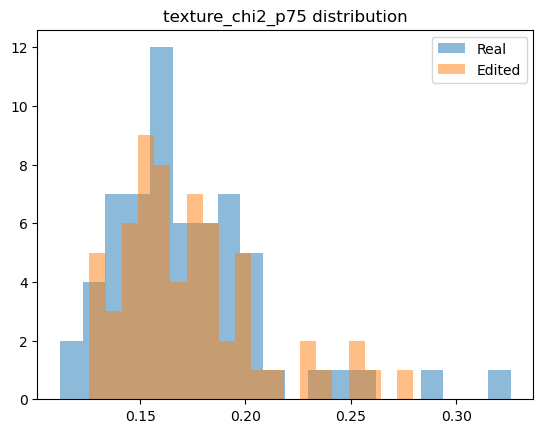

In [7]:
# -----------------------------
# RandomForest (Grouped CV) on ALL features
# -----------------------------
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf_accs = []

for train_idx, test_idx in gkf.split(X_all, y, groups=groups):
    X_tr, X_te = X_all.iloc[train_idx], X_all.iloc[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    rf.fit(X_tr, y_tr)
    preds = rf.predict(X_te)
    rf_accs.append(accuracy_score(y_te, preds))

print("\nRandomForest 5-Fold Grouped CV Accuracy (ALL features):")
print(f"Mean: {np.mean(rf_accs):.4f}")
print(f"Std : {np.std(rf_accs):.4f}")

rf.fit(X_all, y)

importances = pd.Series(rf.feature_importances_, index=X_all.columns)
top_rf = importances.sort_values(ascending=False).head(15)

print("\nTop RandomForest Features:")
print(top_rf)

# random guessing baseline
rng = np.random.RandomState(42)
random_preds = rng.randint(0, 2, size=len(y))
print("Random accuracy:", np.mean(random_preds == y))

print("\nMajority-class baseline accuracy:", max((y==0).mean(), (y==1).mean()))

real = X[df_num["label"] == 0]["texture_chi2_p75"]
edited = X[df_num["label"] == 1]["texture_chi2_p75"]

plt.hist(real, bins=20, alpha=0.5, label="Real")
plt.hist(edited, bins=20, alpha=0.5, label="Edited")
plt.legend()
plt.title("texture_chi2_p75 distribution")
plt.show()


The image dataset increased, and the RandomForest (all features) score went from 0.533 +- 0.0319 (with 94 images) to 0.5717 +- 0.021 (with 126 images). This is a 3.8% improvement with more data, lower variance, and the same feature logic.

This could mean that: 
- the features are not just memorizing
- the signal generalizes better with more data
- the earlier 0.59 forward selection result was likely slightly optimistic due to smaller sample size
- the model is stabilizing around 0.57-0.60

With more data:
- structural/meta features weakened in importance
- texture features dominate
- lighting contributes moderately
- depth contributes weak-to-moderate

This tells us that the pipeline might just have a weak-to-moderate signal, which is realistic for handcrafted features.

## module test

In [8]:
CSV_PATH = "features_3.csv"
df = pd.read_csv(CSV_PATH)

def test_feature_set(feature_prefix):
    features = [c for c in df.columns if c.startswith(feature_prefix)]
    X = df[features]
    y = df["label"].values

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X) 

    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    accs = []

    for train_idx, test_idx in kf.split(X_scaled, y):
        X_tr, X_te = X_scaled[train_idx], X_scaled[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]

        model = LogisticRegression(
            l1_ratio=1,
            solver="liblinear",
            max_iter=1000
        )
        model.fit(X_tr, y_tr)
        preds = model.predict(X_te)
        accs.append(accuracy_score(y_te, preds))

    print(f"\n{feature_prefix.upper()}ONLY")
    print(f"Features: {len(features)}")
    print(f"Mean Accuracy: {np.mean(accs):.4f}")
    print(f"Std Dev : {np.std(accs):.4f}")

test_feature_set("texture_")
test_feature_set("lighting_")
test_feature_set("depth_")


TEXTURE_ONLY
Features: 19
Mean Accuracy: 0.5160
Std Dev : 0.0916

LIGHTING_ONLY
Features: 32
Mean Accuracy: 0.3806
Std Dev : 0.0570

DEPTH_ONLY
Features: 18
Mean Accuracy: 0.4289
Std Dev : 0.0552


This tells us which shadow characteristic actually works. It tests each module independently and then combinations to measure true signal strength. Tells us which shadow characteristic matters most, whether my physical assumptions hold, and whether to take out entire modules.

## module quality

In [9]:
# comparing the performance/quality since accuracy can be unstable is small datasets
CSV_PATH = "features_3.csv"
df = pd.read_csv(CSV_PATH)

def test_auc(prefix):
    features = [c for c in df.columns if c.startswith(prefix)]
    X = df[features]
    y = df["label"].values

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    
    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    aucs = []

    for train_idx, test_idx in kf.split(X_scaled, y):
        X_tr, X_te = X_scaled[train_idx], X_scaled[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]

        model = LogisticRegression(
            l1_ratio=1,
            solver="liblinear",
            max_iter=1000
        )
        model.fit(X_tr, y_tr)
        # return a matrix line and select the tampered probability
        probs = model.predict_proba(X_te)[:, 1]
        # given the predicted probabilities for tampered images, how well does the model
        # rank real vs tampered (evaluates all possible thresholds)
        aucs.append(roc_auc_score(y_te, probs))

    print(f"\n{prefix.upper()}ONLY")
    print(f"Mean AUC: {np.mean(aucs):.4f}")
    print(f"Std Dev : {np.std(aucs):.4f}")

test_auc("texture_")
test_auc("lighting_")
test_auc("depth_")


TEXTURE_ONLY
Mean AUC: 0.5198
Std Dev : 0.0594

LIGHTING_ONLY
Mean AUC: 0.4035
Std Dev : 0.0294

DEPTH_ONLY
Mean AUC: 0.4184
Std Dev : 0.0558


This quantifies signal strength by measuring AUC (area under ROC curve). Accuracy is threshold-based and unstable in small sets. AUC measures ranking quality. 

The current features are not separating real vs tampered images properly, which is probably because the features are too aggregated to capture local inconsistencies.

The ROC (receiver operating characteristic) curve shows how well a binary classification model performs. It plots the true positive rate (sensitivity) against the false positive rate (1 - specificity) at different threshold settings. It helps identify the optimal balance between detecting true positives and minimizing false alarms.

AUC (area under curve) is a summary metric where 1.0 is perfect and 0.5 is no better than random guessing (50/50).

For AUC, if:
- tampered probabilities tend to be higher -> AUC > 0.5
- they're randomly mixed -> AUC ≈ 0.5
- real probabilities tend to be higher -> AUC < 0.5

roc_auc_score sorts by predicted probability, compares all positive-negative
pairs, and computes how often prob_positive > prob_negative

**COMPARED TO 94 IMAGES TESTED (refer to srproj_2.ipynb)**


94 images (after texture redesign) (TEXTURE ONLY)
- Accuracy: 0.4333
  - Std (Acc): 0.1090
- AUC: 0.4756
  - Std (AUC): 0.0793


126 images (same texture features) (TEXTURE ONLY)
- Accuracy: 0.5160
  - Std (Acc): 0.0916
- AUC: 0.5198
  - Std (AUC): 0.0594

**KEY POINTS**
- Accuracy increased (8.3% improvement)
- AUC also increased from 0.4756 to 0.5198, which is above 0.5 and means that texture features are now ranking edited images better than random
- Variance (standard deviation) decreased (signal is more stable with more data):
  - accuracy std: 0.109 -> 0.0916
  - AUC std: 0.079 -> 0.059

Without changing the texture logic and only increasing sample size, the texture redesign was not overfitting and it generalized better with more data. IF it were overfitting, performance would have collapsed when adding data. Instead, it improved.

This proves that the patch entropy, clone detection, and removed features:
- introduced real signal
- that signal becomes clearer with more data
- the earlier weaker performance may have been due to small sample noise



Texture-only (0.5160) beats baseline (0.5079), which means that texture alone beats majority class now.

Accuracy is barely above baseline (0.5160 vs 0.5079), so the signal is still weak. **HOWEVER**, AUC > 0.5 confirms it's a real signal.

<mark>An AUC above 0.5 indicates that a classification model is performing better than random guessing at distinguishing between positive and negative classes. Measures the probability that the model ranks a randomly chosen positive instance higher than a randomly chosen negative one. A higher AUC means the model is better at separating the two classes. Ex: AUC of 0.85 means there is an 85% chance that the model will correctly rank a positive case higher than a negative one.</mark>

Key Interpretations of AUC > 0.5:
- 0.5-0.7: poor to fair performance
- 0.7-0.8: acceptable performance
- 0.8-0.9: good performance
- over 0.9: excellent performance

We can tell texture redesign helped because (EMPIRICAL VALIDATION):
- texture-only accuracy increased with more data
- texture-only AUC crossed 0.5
- variance decreased
- texture features dominate importance ranking
- full model performance increased as the dataset grew

EMPIRICAL VALIDATION is confirming accuracy, reliability, and effectiveness of the model or theory using real-world data, observation, and experimentation rather than speculation.


<mark>**NOTE:**</mark>
- accuracy could be improved further by continuing to fix texture (making analysis functions more accurate, adding detection for paint brush/color picker drawn shadows) since texture is currently the strongest signal
- bad-looking visualizations doesn't automatically mean the logic is wrong (DOUBLE CHECK LOGIC AND VISUALS)
- try implementing paint-brush shadow check with frequency/gradient features

## find top individual features

In [11]:
df = pd.read_csv("features_3.csv")

features = [c for c in df.columns if c not in ["filename", "label"]]
y = df["label"].values

results = []

for f in features:
    X = df[[f]].values
    X = StandardScaler().fit_transform(X)

    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    accs = []

    for tr, te in kf.split(X, y):
        model = LogisticRegression(max_iter=2000)
        model.fit(X[tr], y[tr])
        preds = model.predict(X[te])
        accs.append(accuracy_score(y[te], preds))

    results.append((f, np.mean(accs)))

results = sorted(results, key=lambda x: x[1], reverse=True)

print("\nTop 15 Individual Features:")
for f, acc in results[:15]:
    print(f"{f:40s}  {acc:.4f}")


Top 15 Individual Features:
texture_chi2_std                          0.5948
texture_chi2_p25                          0.5643
depth_edge_width_p25                      0.5631
texture_patch_entropy_mean                0.5631
depth_num_dir_samples                     0.5560
lighting_sr_log_ratio_spread              0.5551
lighting_sr_dist_p75                      0.5480
texture_patch_entropy_in_mean             0.5477
lighting_sr_dist_mean                     0.5397
texture_patch_entropy_out_mean            0.5394
depth_edge_width_range                    0.5326
texture_clone_similar_max                 0.5320
depth_edge_width_cv                       0.5317
texture_share_high_chi2                   0.5317
texture_share_low_chi2                    0.5317


List of features we want to consider:
- texture_chi2_std                          0.5948
- texture_chi2_p25                          0.5643
- ~~depth_edge_width_p25                      0.5631~~
- texture_patch_entropy_mean                0.5631
- ~~depth_num_dir_samples                     0.5560~~
- lighting_sr_log_ratio_spread              0.5551
- ~~lighting_sr_dist_p75                      0.5480~~
- texture_patch_entropy_in_mean             0.5477
- lighting_sr_dist_mean                     0.5397
- texture_patch_entropy_out_mean            0.5394
- depth_edge_width_range                    0.5326
- texture_clone_similar_max                 0.5320
- depth_edge_width_cv                       0.5317
- texture_share_high_chi2                   0.5317
- ~~texture_share_low_chi2                    0.5317~~

## reduced feature set (5 features)

In [24]:
CSV_PATH = "features_3.csv"
df = pd.read_csv(CSV_PATH)

# -----------------------------
# manually select core features
# -----------------------------
selected_features = [
    "texture_chi2_std",                 # texture boundary mismatch variability
    "texture_patch_entropy_mean",       # patch texture complexity
    "texture_clone_similar_max",        # clone-ish self-similarity
    "lighting_Yn_iqr",                  # lighting reference spread
    "depth_edge_width_p25",             # depth edge sharpness lower quartile
]

df = df[selected_features + ["label"]]

X = df.drop(columns=["label"])
y = df["label"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
accs = []

for train_idx, test_idx in kf.split(X_scaled, y):
    X_tr, X_te = X_scaled[train_idx], X_scaled[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    model = LogisticRegression(
        l1_ratio=1,
        solver="liblinear",
        max_iter=1000
    )

    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    accs.append(accuracy_score(y_te, preds))

print(df[selected_features].describe())

print("\nReduced Feature Set (5 features) CV Accuracy:")
print(f"Mean: {np.mean(accs):.4f}")
print(f"Std : {np.std(accs):.4f}")

       texture_chi2_std  texture_patch_entropy_mean  \
count        126.000000                  126.000000   
mean           0.068657                    3.032856   
std            0.024362                    0.530331   
min            0.016232                    1.708605   
25%            0.050098                    2.718883   
50%            0.062804                    2.986920   
75%            0.085951                    3.289336   
max            0.138167                    4.434330   

       texture_clone_similar_max  lighting_Yn_iqr  depth_edge_width_p25  
count                 126.000000       126.000000            126.000000  
mean                    0.970225         0.050145              1.627360  
std                     0.022610         0.031548              0.677861  
min                     0.891904         0.009775              0.660435  
25%                     0.953542         0.030189              1.045756  
50%                     0.977147         0.041980           

## trying 8-feature set

In [33]:
CSV_PATH = "features_3.csv"
df = pd.read_csv(CSV_PATH)

# -----------------------------
# manually select core features
# -----------------------------
selected_features = [
    # texture: boundary mismatch distribution (2)
    "texture_chi2_std",
    "texture_chi2_p25",

    # texture: patch entropy distribution (2)
    "texture_patch_entropy_mean",
    "texture_patch_entropy_out_mean",

    # texture: clone (1)
    "texture_clone_similar_max",

    # lighting: brightness reference & consistency (2)
    "lighting_Yn_iqr",
    "lighting_sr_dist_median",

    # depth: edge sharpness (1)
    "depth_edge_width_p25",
]

df = df[selected_features + ["label"]]

X = df.drop(columns=["label"])
y = df["label"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
accs = []

for train_idx, test_idx in kf.split(X_scaled, y):
    X_tr, X_te = X_scaled[train_idx], X_scaled[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    model = LogisticRegression(
        l1_ratio=1,
        solver="liblinear",
        max_iter=1000
    )

    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    accs.append(accuracy_score(y_te, preds))

print("\nReduced Feature Set (8 features) CV Accuracy:")
print(f"Mean: {np.mean(accs):.4f}")
print(f"Std : {np.std(accs):.4f}")


Reduced Feature Set (8 features) CV Accuracy:
Mean: 0.4843
Std : 0.0649


## try refining 5 feature set and do Logistic Regression

In [36]:
CSV_PATH = "features_3.csv"
df = pd.read_csv(CSV_PATH)

# -----------------------------
# manually select core features
# -----------------------------
selected_features = [
    "texture_chi2_std",                 # texture boundary mismatch variability
    "texture_patch_entropy_mean",       # patch texture complexity
    "texture_clone_similar_max",        # clone-ish self-similarity
    "lighting_Yn_iqr",                  # lighting reference spread
    "depth_edge_width_p25",             # depth edge sharpness lower quartile
]

df = df[selected_features + ["label"]]

X = df.drop(columns=["label"])
y = df["label"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
accs = []

for train_idx, test_idx in kf.split(X_scaled, y):
    X_tr, X_te = X_scaled[train_idx], X_scaled[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    model = LogisticRegression(
        l1_ratio=1,
        solver="liblinear",
        max_iter=1000
    )

    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    accs.append(accuracy_score(y_te, preds))

print(df[[
    "texture_clone_similar_max",
    "lighting_Yn_iqr",          
    "depth_edge_width_p25"     
]].corr())

print(df[selected_features].describe())

print("\nReduced Feature Set (5 features) CV Accuracy:")
print(f"Mean: {np.mean(accs):.4f}")
print(f"Std : {np.std(accs):.4f}")

                           texture_clone_similar_max  lighting_Yn_iqr  \
texture_clone_similar_max                   1.000000         0.136237   
lighting_Yn_iqr                             0.136237         1.000000   
depth_edge_width_p25                       -0.005346        -0.370527   

                           depth_edge_width_p25  
texture_clone_similar_max             -0.005346  
lighting_Yn_iqr                       -0.370527  
depth_edge_width_p25                   1.000000  
       texture_chi2_std  texture_patch_entropy_mean  \
count        126.000000                  126.000000   
mean           0.068657                    3.032856   
std            0.024362                    0.530331   
min            0.016232                    1.708605   
25%            0.050098                    2.718883   
50%            0.062804                    2.986920   
75%            0.085951                    3.289336   
max            0.138167                    4.434330   

       text

## RandomForest GroupKFold for the 5-feature set

In [30]:
# choose 5-feature set
five_features = [
    "texture_chi2_std",                 # texture boundary mismatch variability
    "texture_patch_entropy_mean",       # patch texture complexity
    "texture_clone_similar_max",        # clone-ish self-similarity
    "lighting_Yn_iqr",                  # lighting reference spread
    "depth_edge_width_p25",             # depth edge sharpness lower quartile
]

# X should be a DataFrame with all columns (except label/group)
# df_num is your dataframe that includes features + label + group info
X_5 = df_num[five_features]
y = df_num["label"].values

# IMPORTANT: use the same groups you used for GroupKFold
# (example: groups = df_num["group_id"].values OR df_num["base_image"].values)
# assuming you already have `groups` defined:
# groups = df_num["group"].values

# -----------------------------
# RandomForest (Grouped CV) on 5 features
# -----------------------------
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf_accs = []

for train_idx, test_idx in gkf.split(X_5, y, groups=groups):
    X_tr, X_te = X_5.iloc[train_idx], X_5.iloc[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    rf.fit(X_tr, y_tr)
    preds = rf.predict(X_te)
    rf_accs.append(accuracy_score(y_te, preds))

print("\nRandomForest 5-Fold Grouped CV Accuracy (5 features):")
print(f"Mean: {np.mean(rf_accs):.4f}")
print(f"Std : {np.std(rf_accs):.4f}")

# -----------------------------
# Train on all data + importance (5 features only)
# -----------------------------
rf.fit(X_5, y)

importances = pd.Series(rf.feature_importances_, index=X_5.columns)
print("\nRandomForest Importances (5 features):")
print(importances.sort_values(ascending=False))

# -----------------------------
# Baselines
# -----------------------------
rng = np.random.RandomState(42)
random_preds = rng.randint(0, 2, size=len(y))
print("Random accuracy:", np.mean(random_preds == y))
print("Majority-class baseline accuracy:", max((y==0).mean(), (y==1).mean()))


RandomForest 5-Fold Grouped CV Accuracy (5 features):
Mean: 0.5391
Std : 0.0440

RandomForest Importances (5 features):
texture_chi2_std              0.243878
lighting_Yn_iqr               0.212975
texture_patch_entropy_mean    0.187899
depth_edge_width_p25          0.178780
texture_clone_similar_max     0.176469
dtype: float64
Random accuracy: 0.48412698412698413
Majority-class baseline accuracy: 0.5079365079365079


## <mark>**Summary of Current Reduced Sets (126 images)**</mark>

Logistic (5 features)
- Mean: 0.5468
- Std: 0.1117

Logistic (8 features)
- Mean: 0.4843
- Collapsed below baseline

RandomForest (5 features)
- Mean: 0.5391
- Std: 0.0440

Baseline:
- Majority ≈ 0.508
- Random ≈ 0.484

The 5-feature set is pretty decent (for only 5 feature):
- Logistic ≈ 0.547
- RF ≈ 0.539
- (+3-4% above baseline)

The 8-feature set collapses:
- Adding more features made logistic worse (0.484)
- That tells us:
  - The added features introduced noise or redundancy that harmed linear separability

The signal is delicate/sensitive. Adding correlated or weak features can easily:
- Destroy a small margin
- Increase variance
- Confuse logistic regression

RandomForest importances are good:
- texture_chi2_std              0.244
- lighting_Yn_iqr               0.213
- texture_patch_entropy_mean    0.188
- depth_edge_width_p25          0.179
- texture_clone_similar_max     0.176

Balanced; no feature dominates and all modalities contribute.

Earlier 5-feature sets (top individual features) weren't as good because they were:
- Top-ranked individually but overlapping in signal type
- Missing complementary cues

**OVERALL**
Full-feature RF: ~0.572

Compact 5-feature RF: ~0.539

Compact 8-feature: unstable/noisy

This tells us:
- You can compress to 5 features with only ~3% drop in accuracy (actually a strong compression performance).


When SHOULD you use importance?
- Remove extremely weak features
- Remove structural/meta features
- Identify which modalities matter

**Not to directly choose top-5.**

But in this case:
- Feature importance does not equal optimal reduced feature subset because:
  - Importance is conditional
  - Signal is distributed
  - Redundancy exists
  - Interactions matter

A reduced feature set should be based on:
- Individual predictive strength (from single-feature CV results)
- Low redundancy (remove highly correlated duplicates)
- Diversity of signal types (texture boundary + entropy + clone + lighting + depth)
- Cross-validated performance as a group (not individually)

## Forward feature selection (USE THIS ONLY AS A SUPPORTING ANALYSIS, NOT A MAIN RESULT)

In [29]:
def grouped_cv_acc(df, features, y_col, groups, gkf):
    X = df[features].copy()
    y = df[y_col].values

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=3000))
    ])

    accs = []
    for tr, te in gkf.split(X, y, groups=groups):
        pipe.fit(X.iloc[tr], y[tr])
        preds = pipe.predict(X.iloc[te])
        accs.append(accuracy_score(y[te], preds))
    return float(np.mean(accs)), float(np.std(accs))

base = [
    "texture_chi2_std",                 # texture boundary mismatch variability
    "texture_patch_entropy_mean",       # patch texture complexity
    "texture_clone_similar_max",        # clone-ish self-similarity
    "lighting_Yn_iqr",                  # lighting reference spread
    "depth_edge_width_p25"             # depth edge sharpness lower quartile
]

all_features = [c for c in df_num.columns if c not in ["filename","label"]]  # adjust if needed
candidates = [f for f in all_features if f not in base]

best_feats = base[:]
best_mean, best_std = grouped_cv_acc(df_num, best_feats, "label", groups, gkf)
print("Start:", best_mean, best_std, best_feats)

for step in range(1, 11):  # try adding up to 10 more
    best_add = None
    best_add_mean = best_mean
    best_add_std = best_std

    for f in candidates:
        mean, std = grouped_cv_acc(df_num, best_feats + [f], "label", groups, gkf)
        if mean > best_add_mean + 1e-6:
            best_add_mean, best_add_std = mean, std
            best_add = f

    if best_add is None:
        print("No further improvement at step", step)
        break

    best_feats.append(best_add)
    candidates.remove(best_add)
    best_mean, best_std = best_add_mean, best_add_std
    print(f"Step {step}: +{best_add} -> mean={best_mean:.4f} std={best_std:.4f}")

print("Final selected:", best_feats)

Start: 0.5137435897435898 0.09102724447847388 ['texture_chi2_std', 'texture_patch_entropy_mean', 'texture_clone_similar_max', 'lighting_Yn_iqr', 'depth_edge_width_p25']
Step 1: +texture_chi2_mean -> mean=0.5935 std=0.0701
Step 2: +lighting_sr_dist_p75 -> mean=0.6015 std=0.0769
Step 3: +texture_normal_mrl -> mean=0.6092 std=0.0798
Step 4: +texture_clone_similar_count -> mean=0.6175 std=0.0643
Step 5: +lighting_sr_dist_mean -> mean=0.6252 std=0.0702
Step 6: +depth_edge_width_p75 -> mean=0.6265 std=0.0494
Step 7: +texture_chi2_p50 -> mean=0.6422 std=0.0403
Step 8: +texture_chi2_count -> mean=0.6499 std=0.0381
No further improvement at step 9
Final selected: ['texture_chi2_std', 'texture_patch_entropy_mean', 'texture_clone_similar_max', 'lighting_Yn_iqr', 'depth_edge_width_p25', 'texture_chi2_mean', 'lighting_sr_dist_p75', 'texture_normal_mrl', 'texture_clone_similar_count', 'lighting_sr_dist_mean', 'depth_edge_width_p75', 'texture_chi2_p50', 'texture_chi2_count']


## logistic regression with set from forward selection

In [18]:
CSV_PATH = "features_3.csv"
df = pd.read_csv(CSV_PATH)

# manually select core features
selected_features = [
    'depth_edge_width_std', 
    'lighting_Yn_iqr', 
    'lighting_sr_median_median', 
    'texture_patch_entropy_mean', 
    'texture_chi2_mean', 
    'texture_patch_entropy_min', 
    'texture_chi2_p25', 
    'lighting_usable_frac', 
    'lighting_boundary_mrl_iqr',
    'depth_num_measurements'
]

df = df[selected_features + ["label"]]

X = df.drop(columns=["label"])
y = df["label"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
accs = []

for train_idx, test_idx in kf.split(X_scaled, y):
    X_tr, X_te = X_scaled[train_idx], X_scaled[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    model = LogisticRegression(
        l1_ratio=1,
        solver="liblinear",
        max_iter=1000
    )

    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    accs.append(accuracy_score(y_te, preds))

print(df[[
    "depth_edge_width_std", 
    "lighting_Yn_iqr", 
    "lighting_sr_median_median", 
    "texture_patch_entropy_mean", 
    "texture_chi2_mean", 
    "texture_patch_entropy_min", 
    "texture_chi2_p25", 
    "lighting_usable_frac", 
    "lighting_boundary_mrl_iqr",
    "depth_num_measurements"
]].corr())

print(df[selected_features].describe())

print("\nReduced Feature Set (forward selection set) CV Accuracy:")
print(f"Mean: {np.mean(accs):.4f}")
print(f"Std : {np.std(accs):.4f}")

                            depth_edge_width_std  lighting_Yn_iqr  \
depth_edge_width_std                    1.000000         0.268309   
lighting_Yn_iqr                         0.268309         1.000000   
lighting_sr_median_median              -0.130477        -0.077159   
texture_patch_entropy_mean              0.409551        -0.025598   
texture_chi2_mean                      -0.568946        -0.194236   
texture_patch_entropy_min               0.403379         0.104355   
texture_chi2_p25                       -0.029811        -0.052921   
lighting_usable_frac                   -0.262810        -0.148552   
lighting_boundary_mrl_iqr              -0.256119         0.159559   
depth_num_measurements                 -0.291469        -0.292061   

                            lighting_sr_median_median  \
depth_edge_width_std                        -0.130477   
lighting_Yn_iqr                             -0.077159   
lighting_sr_median_median                    1.000000   
texture_patc

## random forest with set from forward selection

In [19]:
# choose 5-feature set
selected_features = [
    'depth_edge_width_std', 
    'lighting_Yn_iqr', 
    'lighting_sr_median_median', 
    'texture_patch_entropy_mean', 
    'texture_chi2_mean', 
    'texture_patch_entropy_min', 
    'texture_chi2_p25', 
    'lighting_usable_frac', 
    'lighting_boundary_mrl_iqr',
    'depth_num_measurements'
]

# X should be a DataFrame with all columns (except label/group)
# df_num is your dataframe that includes features + label + group info
X_5 = df_num[selected_features]
y = df_num["label"].values

# IMPORTANT: use the same groups you used for GroupKFold
# (example: groups = df_num["group_id"].values OR df_num["base_image"].values)
# assuming you already have `groups` defined:
# groups = df_num["group"].values

# RandomForest (Grouped CV) on forward selection features
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf_accs = []

for train_idx, test_idx in gkf.split(X_5, y, groups=groups):
    X_tr, X_te = X_5.iloc[train_idx], X_5.iloc[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    rf.fit(X_tr, y_tr)
    preds = rf.predict(X_te)
    rf_accs.append(accuracy_score(y_te, preds))

print("\nRandomForest 5-Fold Grouped CV Accuracy (forward selection features):")
print(f"Mean: {np.mean(rf_accs):.4f}")
print(f"Std : {np.std(rf_accs):.4f}")

# -----------------------------
# Train on all data + importance (5 features only)
# -----------------------------
rf.fit(X_5, y)

importances = pd.Series(rf.feature_importances_, index=X_5.columns)
print("\nRandomForest Importances (forward selection features):")
print(importances.sort_values(ascending=False))

# -----------------------------
# Baselines
# -----------------------------
rng = np.random.RandomState(42)
random_preds = rng.randint(0, 2, size=len(y))
print("Random accuracy:", np.mean(random_preds == y))
print("Majority-class baseline accuracy:", max((y==0).mean(), (y==1).mean()))


RandomForest 5-Fold Grouped CV Accuracy (forward selection features):
Mean: 0.5487
Std : 0.0722

RandomForest Importances (forward selection features):
lighting_Yn_iqr               0.133401
texture_chi2_p25              0.121136
depth_num_measurements        0.114975
texture_chi2_mean             0.111003
lighting_boundary_mrl_iqr     0.103556
texture_patch_entropy_min     0.098465
lighting_sr_median_median     0.098306
depth_edge_width_std          0.096941
texture_patch_entropy_mean    0.095574
lighting_usable_frac          0.026643
dtype: float64
Random accuracy: 0.48412698412698413
Majority-class baseline accuracy: 0.5079365079365079
